# РТ ОМО 7 Супонова София

## Задание 1

In [1]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense

In [3]:
X = np.random.rand(1000, 20)
y = np.random.randint(2, size=(1000, 1))

model = Sequential()
model.add(Dense(128, input_dim=20, activation='tanh'))
model.add(Dense(1, activation='softmax'))
model.compile(loss='mean_squared_error', optimizer='rmsprop')
model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

model.fit(X, y, epochs=10, batch_size=32)

loss, accuracy = model.evaluate(X, y)
print(f'Loss: {loss}, Accuracy: {accuracy}')

Loss: 0.7014434933662415, Accuracy: 0.5070000290870667


## Задание 2

In [13]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [14]:
from tensorflow import keras
from tensorflow.keras import layers
model = keras.Sequential([
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

In [15]:
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

In [16]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [23]:
model.fit(train_images, train_labels, epochs=20, batch_size=64)

In [24]:
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
predictions[0]

array([1.20742785e-14, 7.07184468e-19, 1.26264331e-12, 1.38194858e-10,
       1.62570159e-22, 4.93613620e-18, 2.83805219e-22, 1.00000000e+00,
       1.32082240e-17, 1.34010413e-12], dtype=float32)

In [25]:
predictions[0].argmax()

np.int64(7)

In [26]:
predictions[0][7]

np.float32(1.0)

In [27]:
test_labels[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [28]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'test_acc: {test_acc}')

test_acc: 0.9837999939918518


```
с batch_size = 64 и epochs = 20 результаты модели оказались еще точнее. вероятность того, что это цифра 7
стала равна 1 (до этого 0,99...). точность на контрольном наборе 0.98, что чуть лучше чем до этого (0.97)
```

## Задание 3

In [41]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = tf.image.resize(train_images[..., tf.newaxis], (96, 96))
test_images = tf.image.resize(test_images[..., tf.newaxis], (96, 96))

train_images = train_images.numpy().astype("float32") / 255
test_images = test_images.numpy().astype("float32") / 255

print(f"Train shape: {train_images.shape}")
print(f"Test shape: {test_images.shape}")

inputs = keras.Input(shape=(96, 96, 1))

x = layers.Conv2D(filters=32, kernel_size=3, activation="relu", padding="same")(inputs)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=64, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=256, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=512, kernel_size=3, activation="relu", padding="same")(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

Train shape: (60000, 96, 96, 1)
Test shape: (10000, 96, 96, 1)


In [42]:
model.summary()

 Non-trainable params: 0 (0.00 B)

In [43]:
model.compile(optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])
model.fit(train_images, train_labels, epochs=10, batch_size=64)

test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

Test accuracy: 0.991


## Задание 4

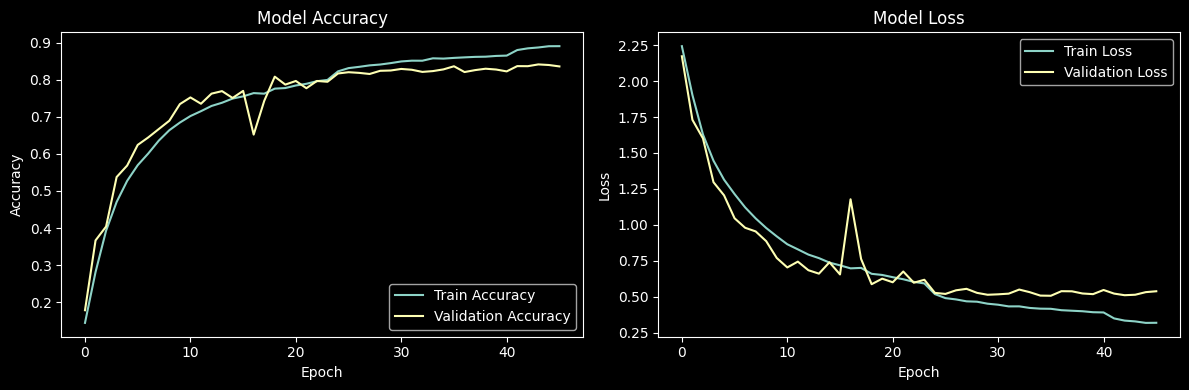

In [46]:
import numpy as np
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from keras.optimizers import SGD

np.random.seed(42)

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

def create_improved_model():
    model = Sequential()

    model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))

    return model

model = create_improved_model()

sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

model.compile(loss='categorical_crossentropy',
              optimizer=sgd,
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

history = model.fit(X_train, y_train_cat,
                    batch_size=64,
                    epochs=50,
                    validation_split=0.1,
                    shuffle=True,
                    callbacks=[early_stop, reduce_lr],
                    verbose=1)

scores = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Точность на тестовых данных: {scores[1]*100:.2f}%")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [47]:
model_final = create_improved_model()
model_final.compile(loss='categorical_crossentropy',
                    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
                    metrics=['accuracy'])

early_stop_final = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True)

history_final = model_final.fit(X_train, y_train_cat,
                                batch_size=64,
                                epochs=100,
                                shuffle=True,
                                callbacks=[early_stop_final],
                                verbose=1)

scores_final = model_final.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nФинальная точность на тестовых данных: {scores_final[1]*100:.2f}%")


Финальная точность на тестовых данных: 83.49%
